
square | true class: red square
brightness | red pixels | blue pixels | class correct | mask IoU
    0.1    |      0     |       0     |       0       |   0.00
    0.2    |      0     |       0     |       0       |   0.00
    0.3    |      0     |       0     |       0       |   0.00
    0.4    |      0     |       0     |       0       |   0.00
    0.5    |      0     |       0     |       0       |   0.00
    0.6    |    121     |       0     |       1       |   1.00
    0.7    |    121     |       0     |       1       |   1.00
    0.8    |    121     |       0     |       1       |   1.00
    0.9    |    121     |       0     |       1       |   1.00

circle | true class: blue circle
brightness | red pixels | blue pixels | class correct | mask IoU
    0.1    |      0     |       0     |       1       |   0.00
    0.2    |      0     |       0     |       1       |   0.00
    0.3    |      0     |       0     |       1       |   0.00
    0.4    |      0     |       0     |       1

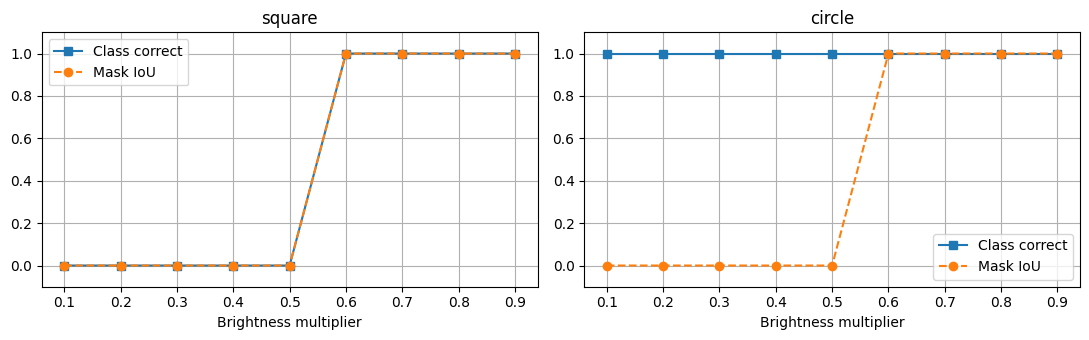

In [2]:
### CS231n_Lec01_review_CV_Tasks showing pixel sensitivity to brightness


import numpy as np
import matplotlib.pyplot as plt

H = W = 32
NAMES = ("red square", "blue circle")

## define the function to make arbitrary sample(red square OR blue circle)
def make_scene(kind, cx, cy, radius=5):
    image = np.full((H, W, 3), 0.08, dtype=np.float32)

    # np.mgrid → Create array of row and column coordinates for all pixels
    yy, xx = np.mgrid[:H, :W]

    if kind == "square":
        # mask → A Boolean mask array defining a shape region using a mathematical expression.
        mask = (abs(xx - cx) <= radius) & (abs(yy - cy) <= radius)
        color, label = (1.0, 0.15, 0.15), 0
    else:
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
        color, label = (0.15, 0.25, 1.0), 1

    # Coloring the shape area by applying a mask array
    image[mask] = color
    return image, label, mask


## define the function to classify pixel-label
def fixed_threshold(image):

    # Set simple decision rules vulnerable to brightness changes.
    red = image[..., 0] > 0.5
    blue = image[..., 2] > 0.5

    # Compare the number of pixels by color standards
    """ important point-if there is nothing detected, the result is blue circle → bias risk"""
    predicted_class = 0 if red.sum() > blue.sum() else 1
    predicted_mask = red | blue


    return predicted_class, predicted_mask, red.sum(), blue.sum()


## define the function to calculate the intersection-to-union ratio
def iou(true_mask, predicted_mask):
    intersection = np.logical_and(true_mask, predicted_mask).sum()
    union = np.logical_or(true_mask, predicted_mask).sum()
    return intersection / union if union else 1.0

## create the arbitrary shape sample group by designed functions

scenes = (
    ("square", make_scene("square", cx=10, cy=12)),
    ("circle", make_scene("circle", cx=22, cy=18)),
)

## set the brightness values(0.1-0.9) to observe pixel sensitivity
brightness_values = np.linspace(0.1, 0.9, 9)

## create subplot with two separate axis
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))


## Loops to predict image labels & areas, compare predicted results <-> target, and visualize
## with each sample and different brightness
for ax, (name, scene) in zip(axes, scenes):
    image, true_class, true_mask = scene
    class_correct = []
    mask_scores = []

    print(f"\n{name} | true class: {NAMES[true_class]}")
    print("brightness | red pixels | blue pixels | class correct | mask IoU")

    for brightness in brightness_values:
        sample = image * brightness

        # predict the label & area
        predicted_class, predicted_mask, red_count, blue_count = (
            fixed_threshold(sample)
        )

        # compare the prediction <-> target and calculate scores
        correct = int(predicted_class == true_class)
        score = iou(true_mask, predicted_mask)

        # save the correct values(0 or 1) and scores
        class_correct.append(correct)
        mask_scores.append(score)

        print(
            f"    {brightness:.1f}    |"
            f"    {red_count:3d}     |"
            f"     {blue_count:3d}     |"
            f"       {correct}       |"
            f"   {score:.2f}"
        )

    ## visualize correct values and scores using matplotli tools
    ax.plot(brightness_values, class_correct, "s-", label="Class correct")
    ax.plot(brightness_values, mask_scores, "o--", label="Mask IoU")
    ax.set_title(name)
    ax.set_xlabel("Brightness multiplier")
    ax.set_xticks(brightness_values)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()